In [10]:
import os
import sys
import random
from typing import Dict, Optional
import logging

from rdkit import Chem
from rdkit.Chem import Draw

curr_file_dir = os.getcwd()
parent_dir = os.path.dirname(curr_file_dir)
sys.path.append(os.path.join(parent_dir, 'protac_splitter'))

from protac_splitter.evaluation import (
    check_reassembly,
    split_prediction,
)
from protac_splitter.chemoinformatics import (
    dummy2query,
    canonize,
    remove_dummy_atoms,
)
from protac_splitter.data.curation.substructure_extraction import get_attachment_bonds

In [2]:
protac_examples = [
        [
            'N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(N4CCN(CCCCCNc5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cc3)CC2)cc1Cl',
            '[*:1]N[C@@H]2CC[C@@H](Oc1ccc(C#N)c(Cl)c1)CC2.[*:2]CCCCCN2CCN(c1ccc(C([*:1])=O)cc1)CC2.[*:2]Nc3ccc2c(=O)n(C1CCC(=O)NC1=O)c(=O)c2c3',
        ],
        [
            'CN(c1ccc(C#N)c(Cl)c1)[C@H]1CC[C@H](NC(=O)c2ccc(N3CC(CN4CCN(c5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)C3)cc2)CC1',
            '[*:1]N[C@@H]2CC[C@@H](N(C)c1ccc(C#N)c(Cl)c1)CC2.[*:1]C(=O)c3ccc(N2CC(CN1CCN([*:2])CC1)C2)cc3.[*:2]c3ccc2c(=O)n(C1CCC(=O)NC1=O)c(=O)c2c3',
        ],
        [
            'CN1C(=O)CCc2cc3cc(c21)OCCOCC1CN(C(=O)CCC(=O)NCCCOCCOCCOc2cccc4c2C(=O)N(C2CCC(=O)NC2=O)C4=O)CCN1c1ncc(Cl)c(n1)N3',
            '[*:1]N5CCN4c1ncc(Cl)c(n1)Nc3cc2CCC(=O)N(C)c2c(c3)OCCOCC4C5.[*:2]OCCOCCOCCCNC(=O)CCC([*:1])=O.[*:2]c2cccc3c(=O)n(C1CCC(=O)NC1=O)c(=O)c23',
        ],
        [
            'N#CC1(CNc2cccc(-c3cc(N[C@H]4CC[C@H](NCC(=O)NCCOCCOCCOCCNc5cccc6c5C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)ncc3Cl)n2)CCOCC1',
            '[*:1]C(=O)CN[C@@H]4CC[C@@H](Nc3cc(c2cccc(NCC1(C#N)CCOCC1)n2)c(Cl)cn3)CC4.[*:2]NCCOCCOCCOCCN[*:1].[*:2]c2cccc3c(=O)n(C1CCC(=O)NC1=O)c(=O)c23',
        ],
        [
            'O=C1CCC(N2C(=O)c3ccc(OCCOCCOCCOCCN4CCN(Cc5ccc6nc(NC(=O)c7cccc(C(F)(F)F)c7)n([C@H]7CC[C@@H](CO)CC7)c6c5)CC4)cc3C2=O)C(=O)N1',
            '[*:2]c3ccc2c(=O)n(C1CCC(=O)NC1=O)c(=O)c2c3.[*:1]CN1CCN(CCOCCOCCOCCO[*:2])CC1.[*:1]c4ccc3nc(NC(=O)c1cccc(C(F)(F)F)c1)n([C@@H]2CC[C@H](CO)CC2)c3c4',
        ],
        [
            'N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(N4CCN(CCCCNc5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cc3)CC2)cc1Cl',
            '[*:1]N[C@@H]2CC[C@@H](Oc1ccc(C#N)c(Cl)c1)CC2.[*:2]NCCCCN2CCN(c1ccc(C([*:1])=O)cc1)CC2.[*:2]c3ccc2c(=O)n(C1CCC(=O)NC1=O)c(=O)c2c3',
        ],
        [
            'Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)COCCOCCOCCNC(=O)CCC(=O)N2CCN([C@H]3CC[C@@H](Nc4ncnn5ccc(C(C)C)c45)CC3)CC2)C(C)(C)C)cc1',
            '[*:2]N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc3ccc(c2scnc2C)cc3)C(C)(C)C.[*:1]C(=O)CCC(=O)NCCOCCOCCOCC([*:2])=O.[*:1]N4CCN([C@@H]3CC[C@H](Nc1ncnn2ccc(C(C)C)c12)CC3)CC4',
        ],
        [
            'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)CNC(=O)c2cccc(-c3ccc(N4CCN(C)CC4)c(NC(=O)c4c[nH]c(=O)cc4C(F)(F)F)c3)c2)C(C)(C)C)cc1',
            '[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc3ccc(c2scnc2C)cc3)C(C)(C)C.[*:1]NCC([*:2])=O.[*:1]C(=O)c4cccc(c3ccc(N1CCN(C)CC1)c(NC(=O)c2c[nH]c(=O)cc2C(F)(F)F)c3)c4',
        ],
        [
            'CN1C(=O)CCc2cc3cc(c21)OCCOC[C@H]1CN(C(=O)CCC(=O)NCCCOCCOCCOc2cccc4c2C(=O)N(C2CCC(=O)NC2=O)C4=O)CCN1c1ncc(Cl)c(n1)N3',
            '[*:1]N5CCN4c1ncc(Cl)c(n1)Nc3cc2CCC(=O)N(C)c2c(c3)OCCOC[C@H]4C5.[*:2]OCCOCCOCCCNC(=O)CCC([*:1])=O.[*:2]c2cccc3c(=O)n(C1CCC(=O)NC1=O)c(=O)c23',
        ],
        [
            'CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]1CC[C@H](C(=O)NCCOCCOCCOCCNC(=O)COc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1',
            '[*:1]C(=O)[C@@H]4CC[C@@H](NC(=O)c3cnc(n2ccc1cc(C#N)cnc12)cc3NC(C)C)CC4.[*:1]NCCOCCOCCOCCNC(=O)CO[*:2].[*:2]c2cccc3c(=O)n(C1CCC(=O)NC1=O)c(=O)c23',
        ],

        [
            'CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]1CC[C@H](C(=O)NCCOCCOCCNC(=O)COc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1',
            '[*:1]C(=O)[C@@H]4CC[C@@H](NC(=O)c3cnc(n2ccc1cc(C#N)cnc12)cc3NC(C)C)CC4.[*:1]NCCOCCOCCNC(=O)CO[*:2].[*:2]c2cccc3c(=O)n(C1CCC(=O)NC1=O)c(=O)c23',
        ],
        [
            'Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCNC(=O)CCC(=O)N2CCN([C@H]3CC[C@@H](Nc4ncnn5ccc(C(C)C)c45)CC3)CC2)C(C)(C)C)cc1',
            '[*:2]N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc3ccc(c2scnc2C)cc3)C(C)(C)C.[*:2]C(=O)CCCNC(=O)CCC([*:1])=O.[*:1]N4CCN([C@@H]3CC[C@H](Nc1ncnn2ccc(C(C)C)c12)CC3)CC4',
        ],
        [
            'CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]1CC[C@H](C(=O)NCCOCCNC(=O)COc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1',
            '[*:1]C(=O)c3cnc(n2ccc1cc(C#N)cnc12)cc3NC(C)C.[*:1]N[C@@H]1CC[C@@H](C(=O)NCCOCCNC(=O)CO[*:2])CC1.[*:2]c2cccc3c(=O)n(C1CCC(=O)NC1=O)c(=O)c23',
        ],
        [
            'O=C1CCC(N2C(=O)c3ccc(OCCOCCOCCN4CCN(Cc5ccc6nc(NC(=O)c7cccc(C(F)(F)F)c7)n([C@H]7CC[C@@H](CO)CC7)c6c5)CC4)cc3C2=O)C(=O)N1',
            '[*:2]c3ccc2c(=O)n(C1CCC(=O)NC1=O)c(=O)c2c3.[*:1]CCOCCOCCO[*:2].[*:1]N5CCN(Cc4ccc3nc(NC(=O)c1cccc(C(F)(F)F)c1)n([C@@H]2CC[C@H](CO)CC2)c3c4)CC5',
        ],
        [
            'N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(NCCCNc4ccc5c(c4)C(=O)N(C4CCC(=O)NC4=O)C5=O)cc3)CC2)cc1Cl',
            '[*:1]N[C@@H]2CC[C@@H](Oc1ccc(C#N)c(Cl)c1)CC2.[*:2]NCCCNc1ccc(C([*:1])=O)cc1.[*:2]c3ccc2c(=O)n(C1CCC(=O)NC1=O)c(=O)c2c3',
        ],
        [
            'CC(C)Nc1cc(-n2ccc3cc(C#N)cnc32)ncc1C(=O)N[C@H]1CC[C@H](C(=O)NCCCCNC(=O)COc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1',
            '[*:1]C(=O)c3cnc(n2ccc1cc(C#N)cnc12)cc3NC(C)C.[*:1]N[C@@H]1CC[C@@H](C(=O)NCCCCNC(=O)CO[*:2])CC1.[*:2]c2cccc3c(=O)n(C1CCC(=O)NC1=O)c(=O)c23',
        ],
        [
            'Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CN2CCN(CCN3CCC(O[C@H]4C[C@H](Oc5ccc6c(c5)Sc5cc([N+](=O)[O-])ccc5N6)C4)CC3)CC2)C(C)(C)C)cc1',
            '[*:2]N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@H](C)c3ccc(c2scnc2C)cc3)C(C)(C)C.[*:1]O[C@@H]3C[C@@H](OC2CCN(CCN1CCN(CC([*:2])=O)CC1)CC2)C3.[*:1]c3ccc2[nH]c1ccc(N(=O)=O)cc1sc2c3',
        ],
        [
            'N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(NCCCCCCCCCNc4ccc5c(c4)C(=O)N(C4CCC(=O)NC4=O)C5=O)cc3)CC2)cc1Cl',
            '[*:1]N[C@@H]2CC[C@@H](Oc1ccc(C#N)c(Cl)c1)CC2.[*:2]NCCCCCCCCCNc1ccc(C([*:1])=O)cc1.[*:2]c3ccc2c(=O)n(C1CCC(=O)NC1=O)c(=O)c2c3',
        ],
        [
            'N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(NCCCCCCCCCNc4ccc5c(c4)C(=O)N(C4CCC(=O)NC4=O)C5=O)cc3)CC2)cc1Cl',
            '[*:1]N[C@@H]2CC[C@@H](Oc1ccc(C#N)c(Cl)c1)CC2.[*:2]CCC[*:1].[*:2]c3ccc2c(=O)n(C1CCC(=O)NC1=O)c(=O)c2c3',
        ],
        [
            "CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@H](CC(=O)N1CCC(N2CCC(C#Cc3ccc(C(=O)N[C@H]4C(C)(C)[C@H](Oc5ccc(C#N)c(Cl)c5)C4(C)C)cc3)CC2)CC1)c1ccc(-c2scnc2C)cc1)C(C)(C)C",
            "CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)[*:2])C(C)(C)C.Cc1ncsc1-c1ccc([C@H](CC(=O)N2CCC(N3CCC(C#C[*:1])CC3)CC2)N[*:2])cc1.CC1(C)[C@H](NC(=O)c2ccc([*:1])cc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1",
        ],
    ]

In [3]:
# Set logging level so that we can debug the code
# logging.basicConfig(level=logging.INFO, force=True)
# logger = logging.getLogger(__name__)
# logger.setLevel(logging.INFO)

logging.basicConfig(level=logging.WARNING, force=True)
logger = logging.getLogger(__name__)
logger.setLevel(logging.WARNING)

In [ ]:
def fix_tetrahedral_centers(protac_smiles, pred_smiles):
    protac = Chem.MolFromSmiles(protac_smiles)
    pred_mol = Chem.MolFromSmiles(pred_smiles)

    # Match atoms by substructure alignment
    match = pred_mol.GetSubstructMatch(protac)

    if not match:
        return None

    protac_centers = Chem.FindMolChiralCenters(protac, includeUnassigned=True, useLegacyImplementation=False)
    flipped_pred_centers = Chem.FindMolChiralCenters(pred_mol, includeUnassigned=True, useLegacyImplementation=False)

    protac_centers = [idx for idx, _ in protac_centers]
    flipped_pred_centers = [idx for idx, _ in flipped_pred_centers]
    
    # Check if the indeces are the same, if not, return None
    if any(i1 != i2 for i1, i2 in zip(protac_centers, flipped_pred_centers)):
        return None

    # Iterate through the reference molecule to set explicit chirality
    for atom_idx in protac_centers:
        # Get the atoms from both molecules
        protac_atom = protac.GetAtomWithIdx(atom_idx)
        pred_atom = pred_mol.GetAtomWithIdx(atom_idx)
    
        protac_tag = protac_atom.GetChiralTag()
        # pred_tag = pred_atom.GetChiralTag() # Unused in this context
    
        # Set the prediction's chirality explicitly to match the reference
        if protac_tag != Chem.ChiralType.CHI_UNSPECIFIED:
            pred_atom.SetChiralTag(protac_tag)

    # Sanitize after setting explicit chirality
    Chem.SanitizeMol(pred_mol)

    return canonize(Chem.MolToSmiles(pred_mol))

def fix_tetrahedral_centers_ligand(
        protac_mol: Chem.Mol,
        ligand_smiles: str,
        attachment_id: int = 1,
) -> str:
    ligand_mol = Chem.MolFromSmiles(ligand_smiles)
    if ligand_mol is None:
        logging.error(f"Invalid ligand SMILES: {ligand_smiles}")
        return None

    ligand_mol = remove_dummy_atoms(ligand_mol)
    ligand_match = protac_mol.GetSubstructMatch(ligand_mol, useChirality=False) # useChirality=True

    # Get bonds to break to separate the POI ligand
    bonds_to_break_poi = get_attachment_bonds(protac_mol, ligand_match)

    # Return if no bonds are found
    if len(bonds_to_break_poi) != 1:
        logging.error('ERROR: Multiple POI attachment bonds')
        return None

    # Break the bonds to isolate the POI ligand
    frag_ligand_mol = Chem.FragmentOnBonds(protac_mol, bonds_to_break_poi, addDummies=True, dummyLabels=[(attachment_id, attachment_id)])

    # Get the fragments resulting from bond breaking
    try:
        frags = Chem.GetMolFrags(frag_ligand_mol, asMols=True, sanitizeFrags=True)
    except Exception as e:
        logging.error(e)
        return None

    # Identify the ligand fragment
    ligand_fragment = None
    for frag in frags:
        if frag.HasSubstructMatch(ligand_mol):
            ligand_fragment = frag
            break
    if ligand_fragment is None:
        logging.error('ERROR: POI fragment not found')

    ligand_fixed = Chem.MolToSmiles(ligand_fragment)
    ligand_fixed = canonize(ligand_fixed.replace(f'[{attachment_id}*]', f'[*:{attachment_id}]'))
    return ligand_fixed


def remove_attach_atom(mol: Chem.Mol, attach_id: int) -> Chem.Mol:
    """ Removes the atom with the specified attachment id from the molecule.

    Example:
    
    >>> remove_attach_atom(Chem.MolFromSmiles('CC[*:1]'), 1)
    CC

    There are no checks on the molecule, so it is assumed it is not None.

    Args:
        mol (Chem.Mol): The molecule.
        attach_id (int): The attachment id of the atom to remove.

    Returns:
        (Chem.Mol) The molecule with the atom removed.
    """
    atoms_to_remove = []
    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() == 0:  # Dummy atom
            map_num = atom.GetAtomMapNum()
            if map_num == attach_id:  # Targeting only [*:attach_id]
                atoms_to_remove.append(atom.GetIdx())

    # Remove atoms using an EditableMol
    editable_mol = Chem.EditableMol(mol)
    for idx in sorted(atoms_to_remove, reverse=True):  # Remove from highest index to avoid shifting
        editable_mol.RemoveAtom(idx)

    # Convert back to a molecule
    new_mol = editable_mol.GetMol()
    Chem.SanitizeMol(new_mol)
    return new_mol

def check_reassembly(
        protac_smiles: str,
        ligands_smiles: str,
        stats: Optional[Dict[str, int]] = None,
        linker_can_be_null: bool = False,
        poi_attachment_id: int = 1,
        e3_attachment_id: int = 2,
        verbose: int = 0,
        return_reassembled_smiles: bool = False,
) -> bool:
    """Check if the reassembled PROTAC matches the original PROTAC SMILES.

    Args:
        protac_smiles (str): The original PROTAC SMILES.
        ligands_smiles (str): The SMILES of the joined PROTAC ligands, separated by a "." (dot).
        stats (Optional[Dict[str, int]]): A dictionary to store statistics about the reassembly process.
        linker_can_be_null (bool): If False, the linker cannot be empty, and if so, a None will be returned. If True, a special check is performed to rename the E3 and WH attchament points to assemble them together.
        poi_attachment_id (int): The label of the attachment point for the POI ligand, i.e., "[*:{poi_attachment_id}]". Default is 1.
        e3_attachment_id (int): The label of the attachment point for the E3 binder, i.e., "[*:{e3_attachment_id}]". Default is 2.
        verbose (int): The verbosity

    Returns:
        bool: True if the reassembled PROTAC matches the original PROTAC SMILES, False otherwise. None if it failed.
    """
    ligands_smiles = canonize(ligands_smiles)
    if ligands_smiles is None:
        if verbose:
            logging.error('Ligand could be canonicalized.')
        return (False, None) if return_reassembled_smiles else False

    null_linker_e3 = f'[*:{e3_attachment_id}][*:{poi_attachment_id}]'
    null_linker_poi = f'[*:{poi_attachment_id}][*:{e3_attachment_id}]'
    linker_is_null = False
    if null_linker_e3 in ligands_smiles or null_linker_poi in ligands_smiles:
        # If the linker is empty, remove the linker atoms
        ligands_smiles = ligands_smiles.replace(null_linker_poi, '')
        ligands_smiles = ligands_smiles.replace(null_linker_e3, '')
        ligands_smiles = ligands_smiles.replace('..', '.')
        ligands_smiles = ligands_smiles.rstrip('.')
        ligands_smiles = ligands_smiles.lstrip('.')
        ligands_smiles = canonize(ligands_smiles)
        linker_is_null = True

    # if linker_can_be_null or linker_is_null:
    #     if len(ligands_smiles.split('.')) == 2:
    #         # Replace the attachment points with a third one (they will be joined later)
    #         ligands_smiles = rename_attachment_id(ligands_smiles, e3_attachment_id, max([poi_attachment_id, e3_attachment_id]) + 1)
    #         ligands_smiles = rename_attachment_id(ligands_smiles, poi_attachment_id, max([poi_attachment_id, e3_attachment_id]) + 1)

    ligands_mol = Chem.MolFromSmiles(ligands_smiles)
    if ligands_mol is None:
        if verbose:
            logging.error('ligands_mol is None')
        return (False, None) if return_reassembled_smiles else False

    try:
        reassembled_mol = Chem.molzip(ligands_mol)
        if reassembled_mol is None:
            if stats is not None:
                stats['molzip failed'] += 1
            if verbose:
                logging.error(f'molzip failed')
            return (False, None) if return_reassembled_smiles else False
    except:
        if stats is not None:
            stats['molzip failed (exception)'] += 1
        if verbose:
            logging.error(f'molzip failed (exception)')
        return (False, None) if return_reassembled_smiles else False

    try:
        reassembled_smiles = canonize(Chem.MolToSmiles(reassembled_mol))
        if reassembled_smiles is None:
            if stats is not None:
                stats['MolToSmiles of reassembled failed'] += 1
            if verbose:
                logging.error('MolToSmiles of reassembled failed')
            return (False, None) if return_reassembled_smiles else False
    except:
        if stats is not None:
            stats['MolToSmiles of reassembled failed'] += 1
        if verbose:
            logging.error('MolToSmiles of reassembled failed')
        return (False, None) if return_reassembled_smiles else False

    protac_smiles = canonize(protac_smiles)
    is_equal = protac_smiles == reassembled_smiles

    # if not is_equal:
    #     # Check if the protac molecule has any stereochemistry
    #     fixed_reassembled_smiles = fix_tetrahedral_centers(protac_smiles, reassembled_smiles)
    #     if fixed_reassembled_smiles is not None:
    #         is_equal = protac_smiles == fixed_reassembled_smiles
    #         if is_equal:
    #             reassembled_smiles = fixed_reassembled_smiles

    return (is_equal, reassembled_smiles) if return_reassembled_smiles else is_equal

def fix_prediction(
        protac_smiles: str,
        pred_smiles: str,
        poi_attachment_id: int = 1,
        e3_attachment_id: int = 2,
        remove_stereochemistry: bool = False,
        verbose: int = 0,
) -> Optional[str]:
    """ Fixes a prediction by replacing the substructure that does not match the PROTAC with the rest of the PROTAC.
    
    Args:
        protac_smiles (str): The SMILES of the PROTAC.
        pred_smiles (str): The SMILES of the prediction.
        poi_attachment_id (int): The attachment point id of the POI. Default is 1.
        e3_attachment_id (int): The attachment point id of the E3 ligase. Default is 2.
        verbose (int): The verbosity level. Default is 0.

    Returns:
        A string containing the fixed predictions, or None if the fixing process failed.
    """
    protac_mol = Chem.MolFromSmiles(protac_smiles)
    if protac_mol is None:
        logging.warning(f"Invalid PROTAC SMILES: {protac_smiles}")
        return None
    
    substructs = split_prediction(pred_smiles)

    # If there are at least two None values, there's nothing we can do to fix it
    if sum(v is None for v in substructs.values()) >= 2:
        logging.warning(f'Unable to continue, more than two substructures are not valid for given input: "{pred_smiles}"')
        return None

    # Get molecules of PROTAC and substructures
    substructs = {k: {'smiles': v, 'mol': Chem.MolFromSmiles(v) if v is not None else v} for k, v in substructs.items()}

    # Check if renaming the attachment points might already fix the prediction
    for sub in ['poi', 'e3', 'both']:
        if sub == 'e3':
            if substructs['e3']['smiles'] is None:
                continue
            e3_attempt = substructs['e3']['smiles'].replace(f'[*:{poi_attachment_id}]', f'[*:{e3_attachment_id}]')
            poi_attempt = substructs['poi']['smiles']
        if sub == 'poi':
            if substructs['poi']['smiles'] is None:
                continue
            e3_attempt = substructs['e3']['smiles']
            poi_attempt = substructs['poi']['smiles'].replace(f'[*:{e3_attachment_id}]', f'[*:{poi_attachment_id}]')
        else:
            if substructs['e3']['smiles'] is None or substructs['poi']['smiles'] is None:
                continue
            e3_attempt = substructs['e3']['smiles'].replace(f'[*:{e3_attachment_id}]', f'[*:{poi_attachment_id}]')
            poi_attempt = substructs['poi']['smiles'].replace(f'[*:{poi_attachment_id}]', f'[*:{e3_attachment_id}]')

        protac_attempt = f"{e3_attempt}.{substructs['linker']['smiles']}.{poi_attempt}"
        if check_reassembly(
            protac_smiles,
            protac_attempt,
        ):
            logging.info(f'Input works when renaming attachment points in {sub.title()} substruct. SMILES: "{protac_attempt}"')
            return protac_attempt
    
        # Check if swapping the POI and E3 attachments in the linker might already fix the prediction
        if substructs['linker']['smiles'] is None:
            continue
        linker_attempt = substructs['linker']['smiles']
        linker_attempt = linker_attempt.replace(f'[*:{poi_attachment_id}]', f'[*:DUMMY]')
        linker_attempt = linker_attempt.replace(f'[*:{e3_attachment_id}]', f'[*:{poi_attachment_id}]')
        linker_attempt = linker_attempt.replace(f'[*:DUMMY]', f'[*:{e3_attachment_id}]')

        # Try with the original POI and E3 substructures
        protac_attempt = f"{substructs['e3']['smiles']}.{linker_attempt}.{substructs['poi']['smiles']}"
        if check_reassembly(
            protac_smiles,
            protac_attempt,
        ):
            logging.info(f'Input works when swapping POI and E3 attachment points in the linker. Fixed SMILES: "{protac_attempt}"')
            return protac_attempt

        # Try with the swapped POI and E3 substructures
        protac_attempt = f"{e3_attempt}.{linker_attempt}.{poi_attempt}"
        if check_reassembly(
            protac_smiles,
            protac_attempt,
        ):
            logging.info(f'Input works when swapping POI and E3 attachment points in the linker and in {sub.title()} substruct. Fixed SMILES: "{protac_attempt}"')
            return protac_attempt

    # Check if removing stereochemistry results in a valid prediction
    if remove_stereochemistry:
        Chem.RemoveStereochemistry(protac_mol)
        protac_smiles = Chem.MolToSmiles(protac_mol, canonical=True)
        for k, v in substructs.items():
            if v['mol'] is not None:
                Chem.RemoveStereochemistry(v['mol'])
                substructs[k]['smiles'] = Chem.MolToSmiles(v['mol'], canonical=True)

    if all(v['mol'] is not None for v in substructs.values()):
        if check_reassembly(
            protac_smiles,
            '.'.join([v['smiles'] for v in substructs.values()]),
        ):
            logging.info(f'Input works when removing stereochemistry. SMILES: "{pred_smiles}"')
            return f"{substructs['e3']['smiles']}.{substructs['linker']['smiles']}.{substructs['poi']['smiles']}"

    # Check if any of the substructures is NOT a substructure of the PROTAC, if
    # so, we mark it as the wrong substructure to fix.
    # NOTE: Even if the tetrahedral center is not the same between the PROTAC
    # and its substructure, we still consider it a match and eventually fix it
    # later in the function.
    num_matches = 0
    wrong_substruct = None
    for sub in ['poi', 'linker', 'e3']:
        sub_mol = substructs[sub]['mol']
        if sub_mol is None:
            substructs[sub]['match'] = False
            wrong_substruct = sub
        elif protac_mol.HasSubstructMatch(dummy2query(sub_mol)):
            substructs[sub]['match'] = True
            num_matches += 1
        else:
            substructs[sub]['match'] = False
            wrong_substruct = sub

    if num_matches < 2:
        logging.warning(f'Prediction does not contain at least two matching substructures of the PROTAC. Num matches: {num_matches}. Prediction SMILES: "{pred_smiles}"')
        return None

    # If the wrong substructure is still matching in the PROTAC, we need a more
    # complex approach to fix the prediction (see below).
    def remove_substructure(mol, substructure, attachment_id, replaceDummies=False):
        if mol is None or substructure is None:
            return None
        smaller_mol = Chem.ReplaceCore(
            mol,
            substructure,
            labelByIndex=False,
            replaceDummies=replaceDummies,
        )
        if smaller_mol is None:
            logging.warning(f'Failed to remove substructure from prediction SMILES: "{pred_smiles}"')
            return None
        smaller_smiles = Chem.MolToSmiles(smaller_mol, canonical=True)
        smaller_smiles = smaller_smiles.replace('[1*]', f'[*:{attachment_id}]')
        smaller_smiles = smaller_smiles.replace('[2*]', f'[*:{attachment_id}]')
        smaller_mol = canonize(Chem.MolFromSmiles(smaller_smiles))
        return smaller_mol

    # If we still have 3 matches: for each substructure, we progressively remove
    # the other substructures, then we check if the resulting molecule is valid
    # and has only one fragment.
    if num_matches == 3:
        wrong_substruct = None
        for sub in ['poi', 'linker', 'e3']:
            removed_mol = Chem.MolFromSmiles(protac_smiles)

            # Put the current substructure at the end of the list [poi, e3, linker]
            sub_names = ['poi', 'e3', 'linker']
            sub_names.remove(sub)
            sub_names.append(sub)
            # The linker often matches in many parts of the PROTAC, so we remove
            # it when checking the E3 and POI substructures.
            if sub != 'linker':
                sub_names.remove('linker')

            for s in sub_names:
                attachment_id = poi_attachment_id if s == 'poi' else e3_attachment_id
                removed_mol = remove_substructure(
                    removed_mol,
                    dummy2query(substructs[s]['mol']),
                    attachment_id=attachment_id,
                )

            # Check if resulting molecule is None, if so, it is the wrong one
            if removed_mol is None:
                substructs[sub]['match'] = False
                wrong_substruct = sub
                num_matches -= 1
                break

            # Count the number of fragments in the removed molecule
            num_fragments = Chem.GetMolFrags(removed_mol, asMols=True, sanitizeFrags=False)
            if len(num_fragments) > 1:
                substructs[sub]['match'] = False
                wrong_substruct = sub
                num_matches -= 1
                break

    if num_matches == 3:
        logging.warning(f'Prediction already contains all matching substructures of the PROTAC. Prediction SMILES: "{pred_smiles}"')
        return None

    # Get the order in which to remove the substructures and get the final one
    # as the fixed molecule.
    if wrong_substruct == 'linker':
        poi_atoms = substructs['poi']['mol'].GetNumAtoms()
        e3_atoms = substructs['e3']['mol'].GetNumAtoms()
        order = ['poi', 'e3'] if poi_atoms > e3_atoms else ['e3', 'poi']
    else:
        if wrong_substruct == 'poi':
            order = ['e3', 'linker']
        else:
            order = ['poi', 'linker']

    logging.debug(f'Wrong substructure: {wrong_substruct.upper()}. Order: {order}')

    fixed_mol = protac_mol
    for sub in order:
        logging.debug(f'Removing substructure {sub.upper()} from PROTAC.')

        if 'linker' not in order:
            fixed_attach_id = poi_attachment_id if sub == 'poi' else e3_attachment_id
        else:
            fixed_attach_id = poi_attachment_id if 'e3' in order else e3_attachment_id

        if sub == 'linker':
            attach_id = poi_attachment_id if wrong_substruct == 'poi' else e3_attachment_id
            fixed_attach_id = poi_attachment_id if wrong_substruct == 'poi' else e3_attachment_id
            query_mol = remove_attach_atom(substructs[sub]['mol'], attach_id)
            replaceDummies = True
        else:
            query_mol = dummy2query(substructs[sub]['mol'])
            replaceDummies = False

        if verbose:
            # display(Draw.MolToImage(fixed_mol, legend=f"Starting molecule", size=(800, 300)))
            # display(Draw.MolToImage(query_mol, legend=f"Molecule {sub.upper()} to remove", size=(800, 300)))
            pass

        fixed_mol_tmp = remove_substructure(
            fixed_mol,
            query_mol,
            attachment_id=fixed_attach_id,
            replaceDummies=replaceDummies,
        )
        if fixed_mol_tmp is None:
            logging.debug(f'Failed to replace substructure "{sub}" in prediction SMILES: "{pred_smiles}"')
            continue

        fixed_mol = fixed_mol_tmp

        # If there are multiple fragments, keep the biggest one
        fragments = Chem.GetMolFrags(fixed_mol, asMols=True)
        if len(fragments) > 1:
            logging.debug(f'Fixed molecule contains more than one fragment. Keeping the biggest one.')
            max_frag = max(fragments, key=lambda x: x.GetNumAtoms())
            fixed_mol = max_frag

    # Get the SMILES of the fixed molecule
    fixed_smiles = Chem.MolToSmiles(canonize(fixed_mol), canonical=True)
    substructs[wrong_substruct]['smiles'] = fixed_smiles

    if verbose:
        # display(Draw.MolToImage(fixed_mol, legend=f"{wrong_substruct.upper()} fixed molecule: {fixed_smiles}", size=(800, 300)))
        pass

    # Concatenate the substructures check if the re-assembly is correct
    fixed_pred_smiles = f"{substructs['e3']['smiles']}.{substructs['linker']['smiles']}.{substructs['poi']['smiles']}"

    if not check_reassembly(
        protac_smiles,
        fixed_pred_smiles,
    ):
        # Check if by flipping the tetrahedral centers of the ligands we can
        # still fix the prediction.
        protac_mol = canonize(Chem.MolFromSmiles(protac_smiles))
        chiral_centers = Chem.FindMolChiralCenters(
            protac_mol,
            includeUnassigned=True,
            useLegacyImplementation=False,
        )
        if not chiral_centers:
            logging.warning(f"Failed to fix prediction, re-assembly check failed. Generated fixed prediction (failing): {fixed_pred_smiles}")
            return None

        # Get the fixed ligands
        e3_fixed = fix_tetrahedral_centers_ligand(protac_mol, substructs['e3']['smiles'], attachment_id=e3_attachment_id)
        poi_fixed = fix_tetrahedral_centers_ligand(protac_mol, substructs['poi']['smiles'], attachment_id=poi_attachment_id)
        if e3_fixed is None or poi_fixed is None:
            logging.warning(f"Failed to fix prediction, re-assembly check failed. Generated fixed prediction (failing): {fixed_pred_smiles}")
            return None

        # Update the substructures with the fixed ligands and check re-assembly
        substructs['e3']['smiles'] = e3_fixed
        substructs['poi']['smiles'] = poi_fixed
        fixed_pred_smiles = f"{substructs['e3']['smiles']}.{substructs['linker']['smiles']}.{substructs['poi']['smiles']}"
        if not check_reassembly(
            protac_smiles,
            fixed_pred_smiles,
        ):
            logging.warning(f"Failed to fix prediction, re-assembly check failed. Generated fixed prediction (failing): {fixed_pred_smiles}")
            return None

    return fixed_pred_smiles


def make_sub_none(substructs: Dict[str, str]) -> Dict[str, str]:
    """ Makes a random substructure None in the substructs dictionary. """
    sub = random.choice(list(substructs.keys()))
    substructs[sub] = 'wrong_substructure'
    return substructs

def add_atom(substructs: Dict[str, str]) -> Dict[str, str]:
    """ Adds a random atom to a random substructure in the substructs dictionary. """
    subs = ['e3', 'linker', 'poi']
    random.shuffle(subs)
    for sub in subs:
        if 'CC' in substructs[sub]:
            print(f'Removing one atom from substructure: {sub.upper()}')
            substructs[sub] = substructs[sub].replace('CC', 'C', 1)
            break
    return substructs

def add_extra_atoms(substructs: Dict[str, str]) -> Dict[str, str]:
    subs = ['e3', 'linker', 'poi']
    random.shuffle(subs)
    for sub in subs:
        if 'CC' in substructs[sub]:
            num_errors = random.choice([1, 2])
            error_atoms = 'CC' + 'C' * num_errors
            substructs[sub] = substructs[sub].replace('CC', error_atoms, 1)
            print(f'Adding N.{num_errors} atom to substructure: {sub.upper()}')
            break
    return substructs

def alter_atom(substructs: Dict[str, str]) -> Dict[str, str]:
    subs = ['e3', 'linker', 'poi']
    random.shuffle(subs)
    for sub in subs:
        if 'N' in substructs[sub]:
            print(f'Altering one atom from substructure: {sub.upper()}')
            # Randomly select a "N" atom and replace it with "C"
            n_atoms = [i for i, c in enumerate(substructs[sub]) if c == 'N']
            if len(n_atoms) == 0:
                continue
            n_atom = random.choice(n_atoms)
            substructs[sub] = substructs[sub][:n_atom] + 'C' + substructs[sub][n_atom + 1:]
            break
    return substructs

def alter_kirality(substructs: Dict[str, str]) -> Dict[str, str]:
    subs = ['e3', 'linker', 'poi']
    random.shuffle(subs)
    for sub in subs:
        # First get all the indexes of all '@@' and all '@' in the substructure
        clock_indexes = [i for i, c in enumerate(substructs[sub]) if c == '@' and substructs[sub][i + 1] != '@' and substructs[sub][i - 1] != '@']
        anti_indexes = [i for i, c in enumerate(substructs[sub]) if c == '@@']
        if len(clock_indexes) == 0 and len(anti_indexes) == 0:
            continue

        # Randomly select one of the indexes
        if len(clock_indexes) > 0 and len(anti_indexes) > 0:
            select_clock = random.choice([True, False])
        else:
            select_clock = True

        if len(clock_indexes) > 0 and select_clock:
            index = random.choice(clock_indexes)
            # Replace the '@' with '@@'
            if substructs[sub][index] == '@':
                substructs[sub] = substructs[sub][:index] + '@@' + substructs[sub][index + 1:]
                break
        else:
            index = random.choice(anti_indexes)
            # Replace the '@@' with '@'
            if substructs[sub][index:index+1] == '@@':
                substructs[sub] = substructs[sub][:index] + '@' + substructs[sub][index + 2:]
                break
    return substructs

for i in range(5):
    random.seed(42 + i)

    error_functions = [
        # make_sub_none,
        # add_atom,
        # add_extra_atoms,
        # alter_atom,
        alter_kirality,
    ]
    for error_function in error_functions:
        print('-' * 100)
        print(f"Testing error function: {error_function.__name__}")
        print('-' * 100)
        for protac_smiles, pred_smiles in protac_examples:
            protac_smiles = canonize(protac_smiles)
            pred_smiles = canonize(pred_smiles)
            
            protac_mol = Chem.MolFromSmiles(pred_smiles)
            protac_mol = canonize(Chem.molzip(protac_mol))
            protac_smiles = Chem.MolToSmiles(protac_mol, canonical=True)

            substructs = split_prediction(pred_smiles)
            label_smiles = f"{substructs['e3']}.{substructs['linker']}.{substructs['poi']}"

            substructs = error_function(substructs)
            pred_smiles = '.'.join([substructs[s] for s in ['e3', 'linker', 'poi']])
            
            print(f'PROTAC: {protac_smiles}')
            print(f'Label:  {label_smiles}')
            print(f'Pred:   {pred_smiles}')

            fixed_smiles = fix_prediction(protac_smiles, pred_smiles)

            print(f'PROTAC: {protac_smiles}')
            print(f'Pred:   {pred_smiles}')
            print(f'Label:  {label_smiles}')
            print(f'Fixed:  {fixed_smiles}')

            if fixed_smiles is None:
                display(Chem.MolFromSmiles(protac_smiles))

            assert check_reassembly(protac_smiles, fixed_smiles)
            assert fixed_smiles is not None, f'Failed to fix prediction for "{pred_smiles}"'
            # assert fixed_smiles == label_smiles, f'Fixed prediction is not the same as the original prediction for "{pred_smiles}"'
            print('-' * 80)

----------------------------------------------------------------------------------------------------
Testing error function: alter_kirality
----------------------------------------------------------------------------------------------------
PROTAC: N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(N4CCN(CCCCCNc5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cc3)CC2)cc1Cl
Label:  O=C1CCC(N2C(=O)c3ccc(N[*:2])cc3C2=O)C(=O)N1.O=C(c1ccc(N2CCN(CCCCC[*:2])CC2)cc1)[*:1].N#Cc1ccc(O[C@H]2CC[C@H](N[*:1])CC2)cc1Cl
Pred:   O=C1CCC(N2C(=O)c3ccc(N[*:2])cc3C2=O)C(=O)N1.O=C(c1ccc(N2CCN(CCCCC[*:2])CC2)cc1)[*:1].N#Cc1ccc(O[C@@H]2CC[C@H](N[*:1])CC2)cc1Cl
PROTAC: N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(N4CCN(CCCCCNc5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cc3)CC2)cc1Cl
Pred:   O=C1CCC(N2C(=O)c3ccc(N[*:2])cc3C2=O)C(=O)N1.O=C(c1ccc(N2CCN(CCCCC[*:2])CC2)cc1)[*:1].N#Cc1ccc(O[C@@H]2CC[C@H](N[*:1])CC2)cc1Cl
Label:  O=C1CCC(N2C(=O)c3ccc(N[*:2])cc3C2=O)C(=O)N1.O=C(c1ccc(N2CCN(CCCCC[*:2])CC2)cc1)[*:1].N#Cc1ccc(O[C@H]2CC[C@H](N[*:1])CC2)cc1

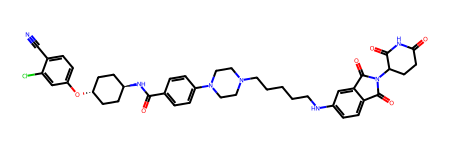

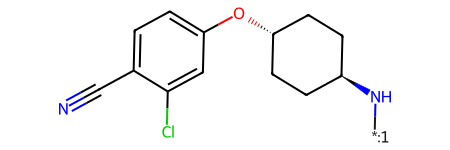

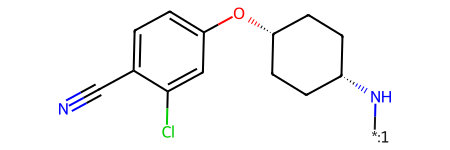

PROTAC chiral centers: [(7, 'r'), (10, 'r'), (37, '?')]
Label chiral centers: [(7, 'r'), (10, 'r')]
Prediction chiral centers: [(7, 's'), (10, 's')]
Label: r, Prediction: s
Flipping atom 7 from s to r
Label: r, Prediction: s
Flipping atom 10 from s to r
Prediction chiral centers after flipping: [(7, 's'), (10, 's')]
PROTAC:         N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(N4CCN(CCCCCNc5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cc3)CC2)cc1Cl
Label:          N#Cc1ccc(O[C@H]2CC[C@H](N[*:1])CC2)cc1Cl
Pred:           N#Cc1ccc(O[C@H]2CC[C@@H](N[*:1])CC2)cc1Cl
Pred (flipped): N#Cc1ccc(O[C@H]2CC[C@@H](N[*:1])CC2)cc1Cl
Matching: False


In [5]:
from typing import Dict, Optional, Union

from rdkit import Chem
from rdkit.Chem import rdCIPLabeler

def canonize_smiles(smiles: str) -> str:
    """ Canonizes a SMILES string by converting it to canonical SMILES representation.
    
    Args:
        smiles (str): The input SMILES string.

    Returns:
        str: The canonized SMILES string.
    """
    if smiles is None:
        return None
    try:
        mol = Chem.MolFromSmiles(smiles)
    except Exception as e:
        print(f"Error: {e}")
        return None
    if mol is None:
        return None
    try:
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None


def canonize(x: Union[str, Chem.Mol]) -> Union[str, Chem.Mol]:
    """ Canonizes a SMILES string or RDKit molecule object.

    Args:
        x: The input SMILES string or RDKit molecule object.

    Returns:
        str | Chem.Mol: The canonized SMILES string or RDKit molecule object, according to the input type.
    """
    if x is None:
        return None
    if isinstance(x, str):
        return canonize_smiles(x)
    return Chem.MolFromSmiles(Chem.MolToSmiles(x, canonical=True))

def flip_chiral_centers(mol, atom_indices_to_flip):
    # mol = Chem.Mol(mol) # clone to avoid modifying input

    # Chem.AssignStereochemistry(mol, force=True, cleanIt=True, flagPossibleStereoCenters=True)
    # rdCIPLabeler.AssignCIPLabels(mol)

    for idx in atom_indices_to_flip:
        atom = mol.GetAtomWithIdx(idx)
        # atom.InvertChirality()
        if atom.HasProp('_CIPCode'):  # only flip if RDKit thinks it's chiral
            atom.InvertChirality()

    # Chem.AssignStereochemistry(mol, force=True, cleanIt=True, flagPossibleStereoCenters=True)
    return mol

def flip_mismatched_centers(mol, label_centers, prediction_centers):
    to_flip = []
    for (i1, label), (i2, pred) in zip(label_centers, prediction_centers):
        assert i1 == i2, "Atom indices do not match"
        print(f"Label: {label}, Prediction: {pred}")
        if label.lower() != pred.lower():
            print(f"Flipping atom {i1} from {pred} to {label}")
            to_flip.append(i1)
    return flip_chiral_centers(mol, to_flip)


protac = "N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(N4CCN(CCCCCNc5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cc3)CC2)cc1Cl"
label = "N#Cc1ccc(O[C@H]2CC[C@H](N[*:1])CC2)cc1Cl"
pred = "N#Cc1ccc(O[C@@H]2CC[C@H](N[*:1])CC2)cc1Cl"

protac = canonize(Chem.MolFromSmiles(protac))
label = canonize(Chem.MolFromSmiles(label))
# pred = canonize(Chem.MolFromSmiles(pred))

# pred = Chem.MolFromSmiles("O=C1CCC(N2C(=O)c3ccc(N[*:2])cc3C2=O)C(=O)N1.O=C(c1ccc(N2CCN(CCCCC[*:2])CC2)cc1)[*:1].N#Cc1ccc(O[C@@H]2CC[C@H](N[*:1])CC2)cc1Cl")
# pred_before_flip = canonize(Chem.molzip(pred))
pred_before_flip = canonize(Chem.MolFromSmiles(pred))

display(protac)
display(label)
display(pred_before_flip)

# # Add Hs to the molecules
# protac = Chem.AddHs(protac)
# label = Chem.AddHs(label)
# pred_before_flip = Chem.AddHs(pred_before_flip)

Chem.AssignStereochemistry(protac, force=True, cleanIt=True)
Chem.AssignStereochemistry(label, force=True, cleanIt=True)
Chem.AssignStereochemistry(pred_before_flip, force=True, cleanIt=True)

# rdCIPLabeler.AssignCIPLabels(protac)
# rdCIPLabeler.AssignCIPLabels(label)
# rdCIPLabeler.AssignCIPLabels(pred_before_flip)

protac_chiral_centers = Chem.FindMolChiralCenters(protac, includeUnassigned=True, useLegacyImplementation=False)
label_chiral_centers = Chem.FindMolChiralCenters(label, includeUnassigned=True, useLegacyImplementation=False)
pred_chiral_centers = Chem.FindMolChiralCenters(pred_before_flip, includeUnassigned=True, useLegacyImplementation=False)
print(f'PROTAC chiral centers: {protac_chiral_centers}')
print(f'Label chiral centers: {label_chiral_centers}')
print(f'Prediction chiral centers: {pred_chiral_centers}')

pred_flipped = flip_mismatched_centers(pred_before_flip, protac_chiral_centers, pred_chiral_centers)
pred_flipped = canonize(pred_flipped)

Chem.AssignStereochemistry(protac, force=True, cleanIt=True)
Chem.AssignStereochemistry(label, force=True, cleanIt=True)
Chem.AssignStereochemistry(pred_flipped, force=True, cleanIt=True)

pred_chiral_centers = Chem.FindMolChiralCenters(pred_flipped, includeUnassigned=True, useLegacyImplementation=False)
print(f'Prediction chiral centers after flipping: {pred_chiral_centers}')



# # Remove Hs from the molecules
# protac = Chem.RemoveHs(protac)
# label = Chem.RemoveHs(label)
# pred_before_flip = Chem.RemoveHs(pred_before_flip)
# pred_flipped = Chem.RemoveHs(pred_flipped)

# Check if their SMILES are the same
print(f'PROTAC:         {Chem.MolToSmiles(protac, canonical=True)}')
print(f'Label:          {Chem.MolToSmiles(label, canonical=True)}')
print(f'Pred:           {Chem.MolToSmiles(pred_before_flip, canonical=True)}')
print(f'Pred (flipped): {Chem.MolToSmiles(pred_flipped, canonical=True)}')

is_matching = Chem.MolToSmiles(protac, canonical=True) == Chem.MolToSmiles(pred_flipped, canonical=True)
print(f'Matching: {is_matching}')

In [6]:
from rdkit import Chem
from protac_splitter.chemoinformatics import remove_dummy_atoms
from protac_splitter.data.curation.substructure_extraction import get_attachment_bonds

def fix_tetrahedral_centers(protac_smiles, pred_smiles):
    protac = Chem.MolFromSmiles(protac_smiles)
    pred_mol = Chem.MolFromSmiles(pred_smiles)

    # Match atoms by substructure alignment
    match = pred_mol.GetSubstructMatch(protac)

    if not match:
        return None

    protac_centers = Chem.FindMolChiralCenters(protac, includeUnassigned=True, useLegacyImplementation=False)
    flipped_pred_centers = Chem.FindMolChiralCenters(pred_mol, includeUnassigned=True, useLegacyImplementation=False)

    protac_centers = [idx for idx, _ in protac_centers]
    flipped_pred_centers = [idx for idx, _ in flipped_pred_centers]
    
    # Check if the indeces are the same, if not, return None
    if any(i1 != i2 for i1, i2 in zip(protac_centers, flipped_pred_centers)):
        return None

    # Iterate through the reference molecule to set explicit chirality
    for atom_idx in protac_centers:
        # Get the atoms from both molecules
        protac_atom = protac.GetAtomWithIdx(atom_idx)
        pred_atom = pred_mol.GetAtomWithIdx(atom_idx)
    
        protac_tag = protac_atom.GetChiralTag()
        # pred_tag = pred_atom.GetChiralTag() # Unused in this context
    
        # Set the prediction's chirality explicitly to match the reference
        if protac_tag != Chem.ChiralType.CHI_UNSPECIFIED:
            pred_atom.SetChiralTag(protac_tag)

    # Sanitize after setting explicit chirality
    Chem.SanitizeMol(pred_mol)

    return canonize(Chem.MolToSmiles(pred_mol))


def fix_tetrahedral_centers_ligand(
        protac_mol: Chem.Mol,
        ligand_smiles: str,
        attachment_id: int = 1,
) -> str:
    ligand_mol = Chem.MolFromSmiles(ligand_smiles)
    if ligand_mol is None:
        logging.error(f"Invalid ligand SMILES: {ligand_smiles}")
        return None

    ligand_mol = remove_dummy_atoms(ligand_mol)
    ligand_match = protac_mol.GetSubstructMatch(ligand_mol, useChirality=False) # useChirality=True

    # Get bonds to break to separate the POI ligand
    bonds_to_break_poi = get_attachment_bonds(protac_mol, ligand_match)

    # Return if no bonds are found
    if len(bonds_to_break_poi) != 1:
        logging.error('ERROR: Multiple POI attachment bonds')
        return None

    # Break the bonds to isolate the POI ligand
    frag_ligand_mol = Chem.FragmentOnBonds(protac_mol, bonds_to_break_poi, addDummies=True, dummyLabels=[(attachment_id, attachment_id)])

    # Get the fragments resulting from bond breaking
    try:
        frags = Chem.GetMolFrags(frag_ligand_mol, asMols=True, sanitizeFrags=True)
    except Exception as e:
        logging.error(e)
        return None

    # Identify the ligand fragment
    ligand_fragment = None
    for frag in frags:
        if frag.HasSubstructMatch(ligand_mol):
            ligand_fragment = frag
            break
    if ligand_fragment is None:
        logging.error('ERROR: POI fragment not found')

    ligand_fixed = Chem.MolToSmiles(ligand_fragment)
    ligand_fixed = canonize(ligand_fixed.replace(f'[{attachment_id}*]', f'[*:{attachment_id}]'))
    return ligand_fixed


protac_smiles = 'N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(N4CCN(CCCCCNc5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cc3)CC2)cc1Cl'
ligands = "O=C1CCC(N2C(=O)c3ccc(N[*:2])cc3C2=O)C(=O)N1.O=C(c1ccc(N2CCN(CCCCC[*:2])CC2)cc1)[*:1].N#Cc1ccc(O[C@@H]2CC[C@H](N[*:1])CC2)cc1Cl"
label = "O=C1CCC(N2C(=O)c3ccc(N[*:2])cc3C2=O)C(=O)N1.O=C(c1ccc(N2CCN(CCCCC[*:2])CC2)cc1)[*:1].N#Cc1ccc(O[C@H]2CC[C@H](N[*:1])CC2)cc1Cl"
# pred_smiles = 'N#Cc1ccc(O[C@H]2CC[C@@H](NC(=O)c3ccc(N4CCN(CCCCCNc5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cc3)CC2)cc1Cl'

pred_smiles = canonize(Chem.MolToSmiles(Chem.molzip(Chem.MolFromSmiles(ligands))))
flipped_smiles = fix_tetrahedral_centers(protac_smiles, pred_smiles)

# Verify the fix
flipped_mol = Chem.MolFromSmiles(flipped_smiles)
protac_centers = Chem.FindMolChiralCenters(protac, includeUnassigned=True, useLegacyImplementation=False)
flipped_pred_centers = Chem.FindMolChiralCenters(flipped_mol, includeUnassigned=True, useLegacyImplementation=False)

print("PROTAC chiral centers:", protac_centers)
print("Flipped Prediction chiral centers:", flipped_pred_centers)

# Check final SMILES if desired
print(f"PROTAC SMILES:     {protac_smiles}")
print(f"Prediction SMILES: {pred_smiles}")
print(f"Corrected SMILES:  {flipped_smiles}")

protac_mol = Chem.MolFromSmiles(protac_smiles)
e3_mol = Chem.MolFromSmiles(ligands.split('.')[0])
lk_mol = Chem.MolFromSmiles(ligands.split('.')[1])
wh_mol = Chem.MolFromSmiles(ligands.split('.')[-1])

e3_fixed = fix_tetrahedral_centers_ligand(protac_mol, ligands.split('.')[0], attachment_id=2)
wh_fixed = fix_tetrahedral_centers_ligand(protac_mol, ligands.split('.')[-1], attachment_id=1)

wh_label = label.split('.')[-1]
print(f"Original POI SMILES:  {wh_label}")
print(f"Wrong POI SMILES:     {ligands.split('.')[-1]}")
print(f"Fixed POI SMILES:     {wh_fixed}")

PROTAC chiral centers: [(7, 'r'), (10, 'r'), (37, '?')]
Flipped Prediction chiral centers: [(7, 'r'), (10, 'r'), (37, '?')]
PROTAC SMILES:     N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(N4CCN(CCCCCNc5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cc3)CC2)cc1Cl
Prediction SMILES: N#Cc1ccc(O[C@H]2CC[C@@H](NC(=O)c3ccc(N4CCN(CCCCCNc5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cc3)CC2)cc1Cl
Corrected SMILES:  N#Cc1ccc(O[C@H]2CC[C@H](NC(=O)c3ccc(N4CCN(CCCCCNc5ccc6c(c5)C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cc3)CC2)cc1Cl
Original POI SMILES:  N#Cc1ccc(O[C@H]2CC[C@H](N[*:1])CC2)cc1Cl
Wrong POI SMILES:     N#Cc1ccc(O[C@@H]2CC[C@H](N[*:1])CC2)cc1Cl
Fixed POI SMILES:     N#Cc1ccc(O[C@H]2CC[C@H](N[*:1])CC2)cc1Cl


In [7]:
# load the csv file: logs/random_split_dataset/PROTAC-Splitter-Trial-11-preds.csv
import pandas as pd

df = pd.read_csv('logs/random_split_dataset/PROTAC-Splitter-Trial-11-preds.csv')
# Filter on the `label_smiles` column byt first splitting the string by `.` and then checking if the n.1 string contains '@'
df['is_linker_chiral'] = df['label_smiles'].apply(lambda x: '@' in x.split('.')[1])
df = df[df['is_linker_chiral']]

# Randomly get a single sample from the dataframe, then isolate the protac_smiles and the label_smiles
sample = df.sample(1, random_state=42)
protac_smiles = sample['protac_smiles'].values[0]
label_smiles = sample['label_smiles'].values[0]
print(f'PROTAC SMILES: {protac_smiles}')
print(f'Label SMILES:  {label_smiles}')

PROTAC SMILES: CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@H](CC(=O)N1CCC(N2CCC(C#Cc3ccc(C(=O)N[C@H]4C(C)(C)[C@H](Oc5ccc(C#N)c(Cl)c5)C4(C)C)cc3)CC2)CC1)c1ccc(-c2scnc2C)cc1)C(C)(C)C
Label SMILES:  CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)[*:2])C(C)(C)C.Cc1ncsc1-c1ccc([C@H](CC(=O)N2CCC(N3CCC(C#C[*:1])CC3)CC2)N[*:2])cc1.CC1(C)[C@H](NC(=O)c2ccc([*:1])cc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1


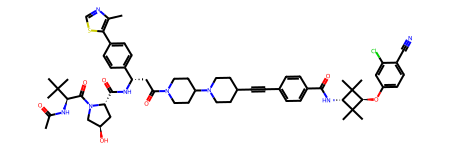

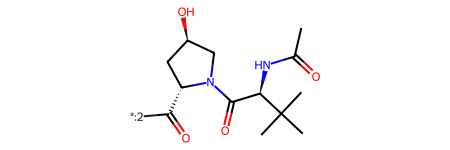

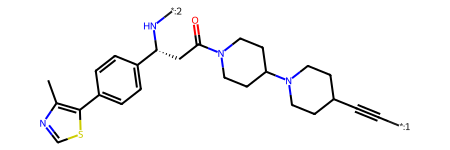

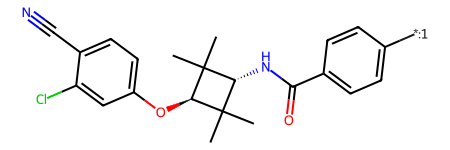

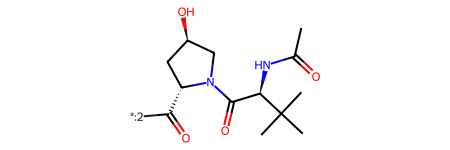

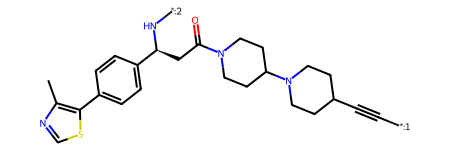

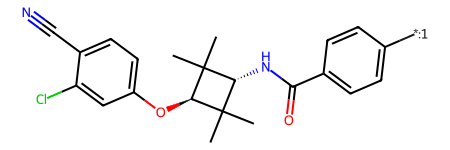

In [8]:
protac_smiles = "CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@H](CC(=O)N1CCC(N2CCC(C#Cc3ccc(C(=O)N[C@H]4C(C)(C)[C@H](Oc5ccc(C#N)c(Cl)c5)C4(C)C)cc3)CC2)CC1)c1ccc(-c2scnc2C)cc1)C(C)(C)C"
label = "CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)[*:2])C(C)(C)C.Cc1ncsc1-c1ccc([C@H](CC(=O)N2CCC(N3CCC(C#C[*:1])CC3)CC2)N[*:2])cc1.CC1(C)[C@H](NC(=O)c2ccc([*:1])cc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1"
ligands = "CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)[*:2])C(C)(C)C.Cc1ncsc1-c1ccc([C@@H](CC(=O)N2CCC(N3CCC(C#C[*:1])CC3)CC2)N[*:2])cc1.CC1(C)[C@H](NC(=O)c2ccc([*:1])cc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1"

display(Chem.MolFromSmiles(protac_smiles))
for l in ligands.split('.'):
    display(Chem.MolFromSmiles(l))
for l in label.split('.'):
    display(Chem.MolFromSmiles(l))